In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon
from scipy.ndimage import gaussian_filter

import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor

Début du traitement par patchs...
Balayage terminé.


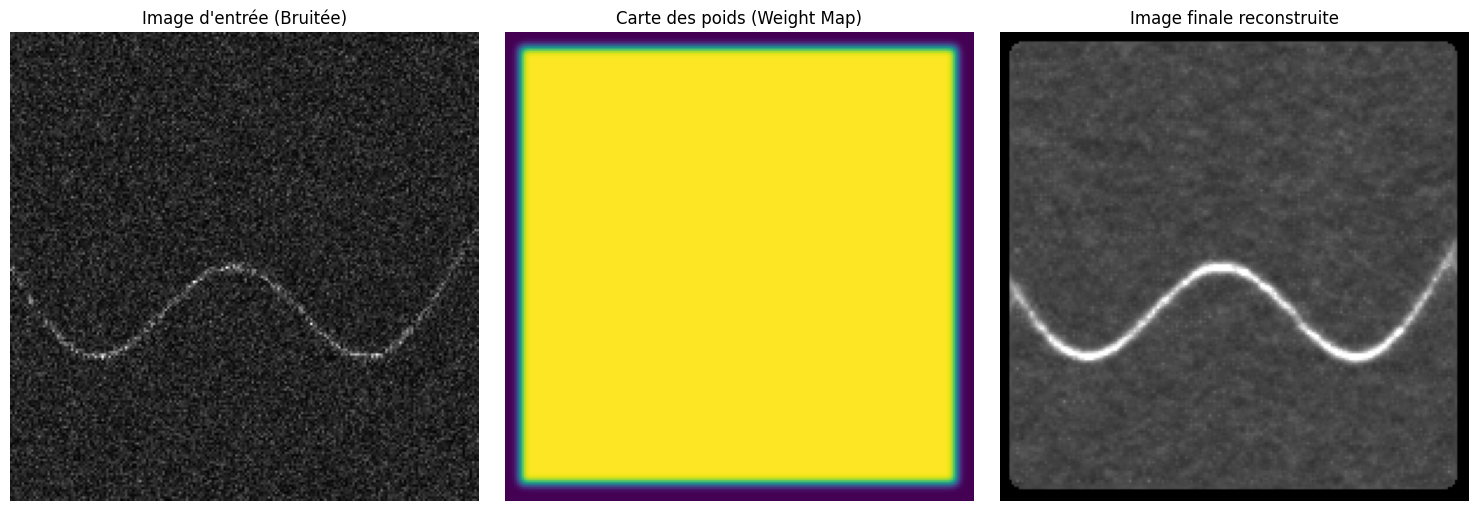

In [3]:
tl.set_backend('numpy')

n_tx, nz, nx = 5, 200, 200 
base_image = np.zeros((nz, nx))

# 1.1 Création de la structure cible
for i in range(nx):
    z_val = int(100 + 50 * np.sin(i / 30.0) * np.cos(i / 60.0))
    if 0 <= z_val < nz:
        base_image[z_val, i] = 1.0 # Intensité de la structure

# 1.2 Ajout d'un fond diffus (échos de tissus)
# On crée une image de base où le fond n'est pas à 0 mais à 0.2
full_scene = base_image + 0.2 
full_scene = gaussian_filter(full_scene, sigma=1.0)

# 1.3 Génération du bruit de Rayleigh sur toute l'image
speckle_images_tx = []
for _ in range(n_tx):
    # Génération du bruit de Rayleigh
    noise_r = np.random.normal(0, 1, (nz, nx))
    noise_i = np.random.normal(0, 1, (nz, nx))
    rayleigh_noise = np.sqrt(noise_r**2 + noise_i**2)
    
    # Application multiplicative sur TOUTE la scène
    noisy_img = full_scene * rayleigh_noise
    
    # Petit bruit blanc électronique en plus (additif)
    noisy_img += 0.02 * np.random.rand(nz, nx)
    
    speckle_images_tx.append(noisy_img)

images_tx = np.array(speckle_images_tx)

# ==========================================
# 2. Paramètres de la fenêtre glissante (ULTIME)
# ==========================================
win_size = 15       
step = 2            # Avancement hyper fin (presque pixel par pixel)
angles_rx = np.linspace(0, 180, 90, endpoint=False) # 90 angles pour une fluidité parfaite

# Création de la fenêtre Gaussienne (Resserrée)
Z_win, X_win = np.indices((win_size, win_size))
center = win_size // 2
sigma = win_size / 6.0  # <--- LE FIX EST ICI : on force les bords à tomber à ~0%
window_2d = np.exp(-((Z_win - center)**2 + (X_win - center)**2) / (2 * sigma**2))

# Toiles vierges
output_image = np.zeros((nz, nx))
weight_map = np.zeros((nz, nx))

# ==========================================
# 3. Boucle de balayage sur toute l'image (CORRIGÉE)
# ==========================================
print("Début du traitement par patchs...")
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        
        # A. Extraction et fenêtrage (Entrée)
        patch_tx = images_tx[:, z:z+win_size, x:x+win_size]
        windowed_patch_tx = patch_tx * window_2d
        
        # B & C. Radon et Tensorly
        # On augmente un peu le seuil pour vraiment ignorer les patchs vides
        if np.max(windowed_patch_tx) < 0.1:
            continue
            
        radon_tensor = np.array([radon(img, theta=angles_rx, circle=False) for img in windowed_patch_tx])
        weights, factors = parafac(radon_tensor, rank=1, init='random', tol=1e-4)
        filtered_radon_tensor = cp_to_tensor((weights, factors))
        
        # D. Matrice f (mid-angle)
        f_sinogram = np.mean(filtered_radon_tensor, axis=0)
        
        # E. Reconstruction locale
        reconstructed_patch = iradon(f_sinogram, theta=angles_rx, circle=False, output_size=win_size)
        
        # ---------------------------------------------------------
        # LE FIX EST ICI :
        # 1. On empêche les valeurs négatives créées par le filtre
        reconstructed_patch = np.clip(reconstructed_patch, 0, None)
        # 2. On réapplique la fenêtre pour écraser les pics sur les bords !
        reconstructed_patch = reconstructed_patch * window_2d
        # ---------------------------------------------------------
        
        # F. OVERLAP-ADD
        output_image[z:z+win_size, x:x+win_size] += reconstructed_patch
        
        # Attention: vu qu'on a appliqué la fenêtre 2 fois (avant radon, et après iradon),
        # le poids total appliqué au pixel est window_2d au carré.
        weight_map[z:z+win_size, x:x+win_size] += (window_2d ** 2)

print("Balayage terminé.")

# ==========================================
# 4. Normalisation de l'image finale (CORRIGÉE)
# ==========================================
final_image = np.zeros_like(output_image)

# FIX 1 : On ne divise que là où la somme des poids est significative
# Cela évite de diviser par presque zéro sur les bords extrêmes de l'image
seuil_poids = 0.1 * np.max(weight_map)
mask = weight_map > seuil_poids

final_image[mask] = output_image[mask] / weight_map[mask]

# --- Affichage ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images_tx[2], cmap='gray')
axes[0].set_title("Image d'entrée (Bruitée)")

axes[1].imshow(weight_map, cmap='viridis')
axes[1].set_title("Carte des poids (Weight Map)")

# FIX 2 : On sature le contraste pour ignorer les artefacts restants
# On demande à Matplotlib de calibrer le blanc sur le 99ème centile (et non sur le pixel max absolu)
if np.any(mask):
    vmax = np.percentile(final_image[mask], 99.5) 
else:
    vmax = 1

axes[2].imshow(final_image**2, cmap='gray', vmin=0, vmax=vmax**2)
axes[2].set_title("Image finale reconstruite")

for ax in axes: 
    ax.axis('off')
    
plt.tight_layout()
plt.show()

Début du traitement par patchs (C'est plus long, l'image est plus grande)...
Balayage terminé.


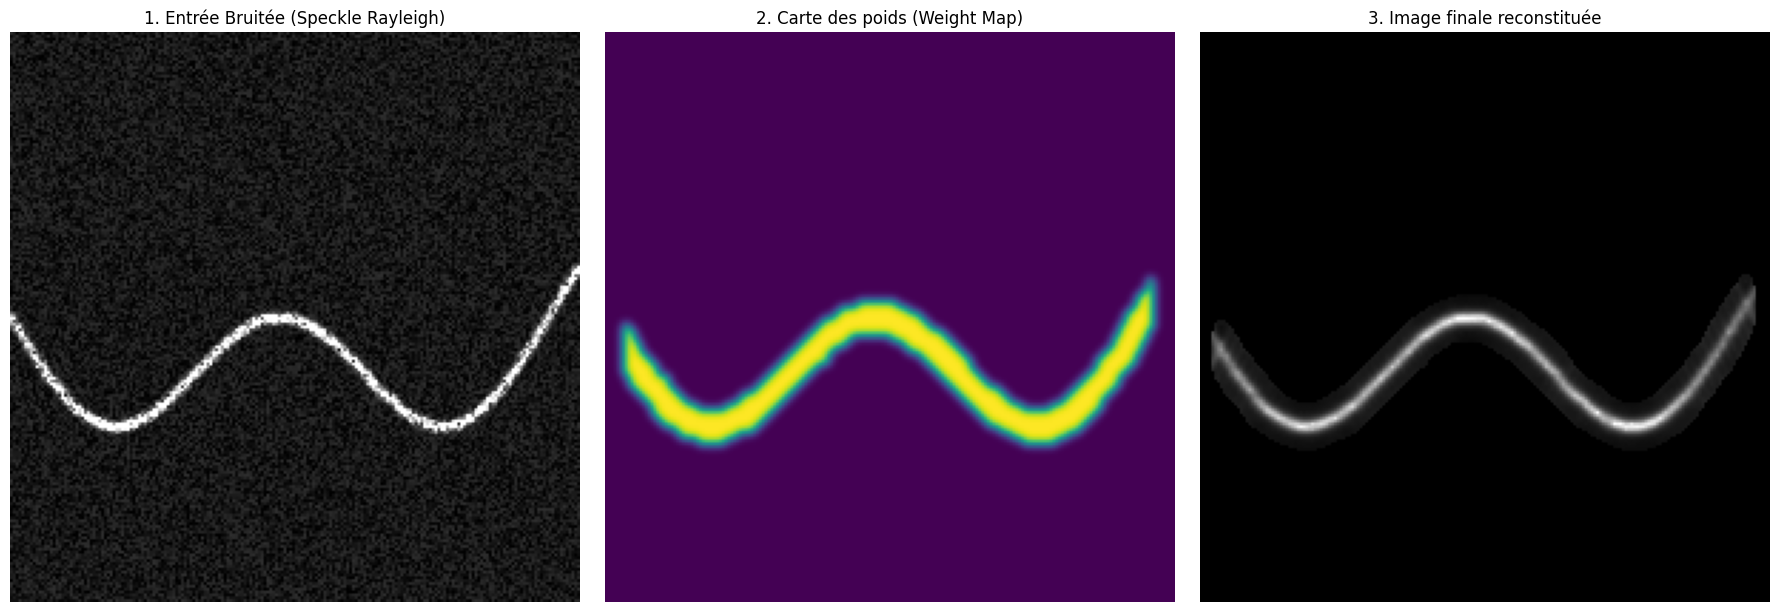

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon
from scipy.ndimage import gaussian_filter
import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor

tl.set_backend('numpy')

# ==========================================
# 1. Création des données (Bruit de Speckle Réaliste)
# ==========================================
# On augmente la résolution pour un meilleur rendu du bruit
n_tx, nz, nx = 5, 200, 200 
base_image = np.zeros((nz, nx))

# Création de la structure courbe (sinusoïde fine)
for i in range(nx):
    # Sinusoïde plus complexe pour le test
    z_val = int(100 + 50 * np.sin(i / 30.0) * np.cos(i / 60.0))
    if 0 <= z_val < nz:
        base_image[z_val, i] = 1
        
# Lissage très léger pour simuler la PSF de la sonde
base_image = gaussian_filter(base_image, sigma=1.0)

# --- GÉNÉRATION DU BRUIT DE SPECKLE (Multiplicatif) ---
# On utilise une distribution de Rayleigh, typique des ultrasons
speckle_images_tx = []
for _ in range(n_tx):
    # Génération d'une carte de bruit de Rayleigh
    # (Obtenue à partir de deux gaussiennes indépendantes)
    noise_r = np.random.normal(0, 1, (nz, nx))
    noise_i = np.random.normal(0, 1, (nz, nx))
    rayleigh_noise = np.sqrt(noise_r**2 + noise_i**2)
    
    # Le bruit est multiplicatif : I_bruitée = I_base * N_rayleigh
    # Cela noie totalement la structure là où le signal est faible
    noisy_img = base_image * rayleigh_noise
    
    # On ajoute un bruit de fond additif très faible
    noisy_img += 0.05 * np.random.uniform(0, 1, (nz, nx))
    
    speckle_images_tx.append(noisy_img)

images_tx = np.array(speckle_images_tx)

# ==========================================
# 2. Paramètres de la fenêtre glissante (Identiques)
# ==========================================
win_size = 15       
step = 2            
angles_rx = np.linspace(0, 180, 90, endpoint=False) 

Z_win, X_win = np.indices((win_size, win_size))
center = win_size // 2
sigma = win_size / 6.0
window_2d = np.exp(-((Z_win - center)**2 + (X_win - center)**2) / (2 * sigma**2))

output_image = np.zeros((nz, nx))
weight_map = np.zeros((nz, nx))

# ==========================================
# 3. Boucle de balayage (Identique)
# ==========================================
print("Début du traitement par patchs (C'est plus long, l'image est plus grande)...")
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        patch_tx = images_tx[:, z:z+win_size, x:x+win_size]
        windowed_patch_tx = patch_tx * window_2d
        
        # Sécurité pour les patchs vides
        if np.max(windowed_patch_tx) < 0.1: # Seuil ajusté pour le speckle
            continue
            
        radon_tensor = np.array([radon(img, theta=angles_rx, circle=False) for img in windowed_patch_tx])
        
        # Décomposition Tensorielle Rang-1
        try:
            weights, factors = parafac(radon_tensor, rank=1, init='random', tol=1e-3, n_iter_max=50)
            filtered_radon_tensor = cp_to_tensor((weights, factors))
            f_sinogram = np.mean(filtered_radon_tensor, axis=0)
            reconstructed_patch = iradon(f_sinogram, theta=angles_rx, circle=False, output_size=win_size)
            reconstructed_patch = np.clip(reconstructed_patch, 0, None)
            reconstructed_patch = reconstructed_patch * window_2d
            output_image[z:z+win_size, x:x+win_size] += reconstructed_patch
            weight_map[z:z+win_size, x:x+win_size] += (window_2d ** 2)
        except:
            # En cas de non-convergence de Tensorly sur un patch trop bruité
            continue

print("Balayage terminé.")

# ==========================================
# 4. Normalisation et Affichage (Amélioré pour le Speckle)
# ==========================================
final_image = np.zeros_like(output_image)
seuil_poids = 0.1 * np.max(weight_map)
mask = weight_map > seuil_poids
final_image[mask] = output_image[mask] / weight_map[mask]

# --- Affichage ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Affichage de l'entrée avec un contraste adapté au speckle
axes[0].imshow(images_tx[2], cmap='gray', vmin=0, vmax=np.percentile(images_tx[2], 99))
axes[0].set_title("1. Entrée Bruitée (Speckle Rayleigh)")

axes[1].imshow(weight_map, cmap='viridis')
axes[1].set_title("2. Carte des poids (Weight Map)")

# Affichage de la sortie (On affine un peu le trait pour compenser le flou)
# Utilisation du 99.9ème centile pour supprimer les derniers artefacts de division
if np.any(mask):
    vmax = np.percentile(final_image[mask], 99.9) 
else:
    vmax = 1
axes[2].imshow(final_image, cmap='gray', vmin=0, vmax=vmax)
axes[2].set_title("3. Image finale reconstituée")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

Début du traitement par patchs (C'est plus long, l'image est plus grande)...
Balayage terminé.


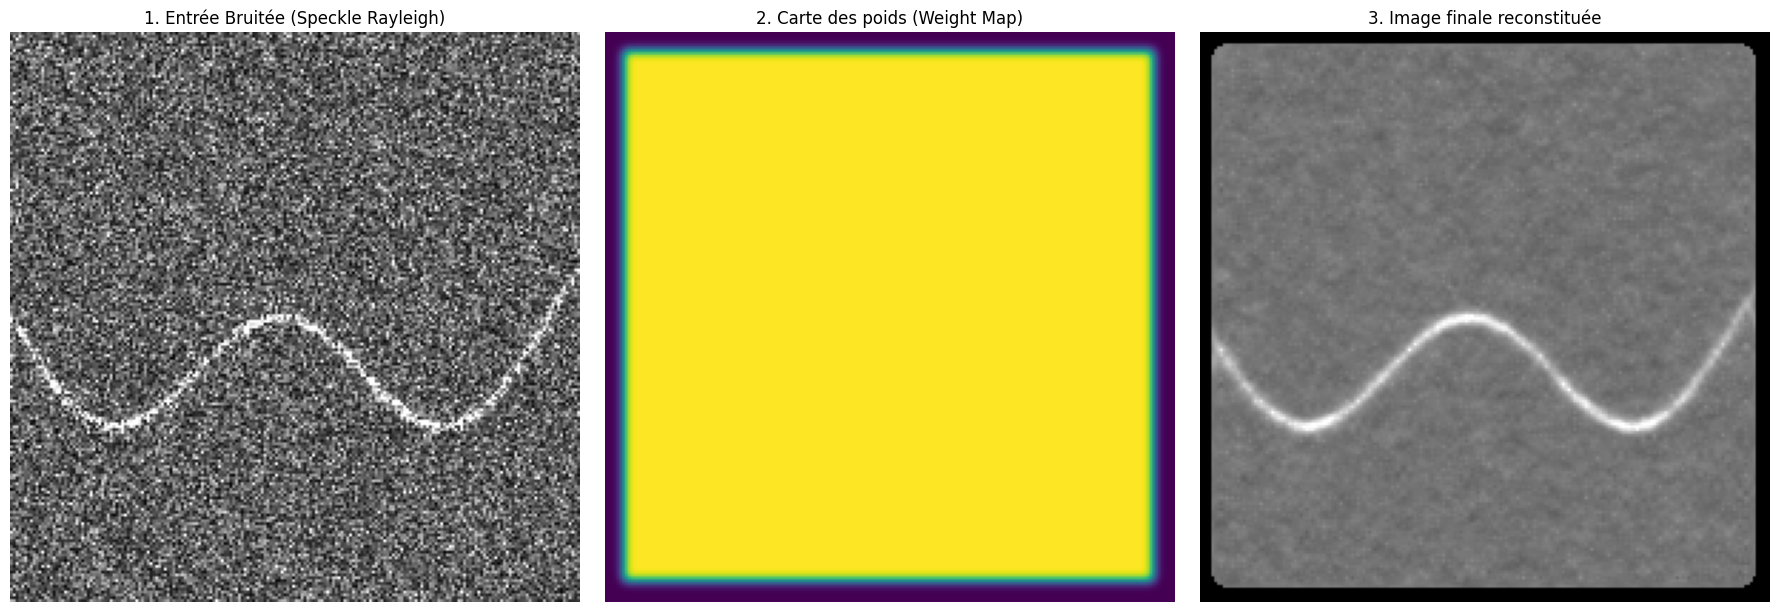

In [5]:
# ==========================================
# 1. Création des données (Bruit de Speckle Global)
# ==========================================
n_tx, nz, nx = 5, 200, 200 
base_image = np.zeros((nz, nx))

# 1.1 Création de la structure cible
for i in range(nx):
    z_val = int(100 + 50 * np.sin(i / 30.0) * np.cos(i / 60.0))
    if 0 <= z_val < nz:
        base_image[z_val, i] = 1.0 # Intensité de la structure

# 1.2 Ajout d'un fond diffus (échos de tissus)
# On crée une image de base où le fond n'est pas à 0 mais à 0.2
full_scene = base_image + 0.2 
full_scene = gaussian_filter(full_scene, sigma=1.0)

# 1.3 Génération du bruit de Rayleigh sur toute l'image
speckle_images_tx = []
for _ in range(n_tx):
    # Génération du bruit de Rayleigh
    noise_r = np.random.normal(0, 1, (nz, nx))
    noise_i = np.random.normal(0, 1, (nz, nx))
    rayleigh_noise = np.sqrt(noise_r**2 + noise_i**2)
    
    # Application multiplicative sur TOUTE la scène
    noisy_img = full_scene * rayleigh_noise
    
    # Petit bruit blanc électronique en plus (additif)
    noisy_img += 0.02 * np.random.rand(nz, nx)
    
    speckle_images_tx.append(noisy_img)

images_tx = np.array(speckle_images_tx)

# ==========================================
# 2. Paramètres de la fenêtre glissante (Identiques)
# ==========================================
win_size = 15       
step = 2            
angles_rx = np.linspace(0, 180, 90, endpoint=False) 

Z_win, X_win = np.indices((win_size, win_size))
center = win_size // 2
sigma = win_size / 6.0
window_2d = np.exp(-((Z_win - center)**2 + (X_win - center)**2) / (2 * sigma**2))

output_image = np.zeros((nz, nx))
weight_map = np.zeros((nz, nx))

# ==========================================
# 3. Boucle de balayage (Identique)
# ==========================================
print("Début du traitement par patchs (C'est plus long, l'image est plus grande)...")
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        patch_tx = images_tx[:, z:z+win_size, x:x+win_size]
        windowed_patch_tx = patch_tx * window_2d
        
        # Sécurité pour les patchs vides
        if np.max(windowed_patch_tx) < 0.1: # Seuil ajusté pour le speckle
            continue
            
        radon_tensor = np.array([radon(img, theta=angles_rx, circle=False) for img in windowed_patch_tx])
        
        # Décomposition Tensorielle Rang-1
        try:
            weights, factors = parafac(radon_tensor, rank=1, init='random', tol=1e-3, n_iter_max=50)
            filtered_radon_tensor = cp_to_tensor((weights, factors))
            f_sinogram = np.mean(filtered_radon_tensor, axis=0)
            reconstructed_patch = iradon(f_sinogram, theta=angles_rx, circle=False, output_size=win_size)
            reconstructed_patch = np.clip(reconstructed_patch, 0, None)
            reconstructed_patch = reconstructed_patch * window_2d
            output_image[z:z+win_size, x:x+win_size] += reconstructed_patch
            weight_map[z:z+win_size, x:x+win_size] += (window_2d ** 2)
        except:
            # En cas de non-convergence de Tensorly sur un patch trop bruité
            continue

print("Balayage terminé.")

# ==========================================
# 4. Normalisation et Affichage (Amélioré pour le Speckle)
# ==========================================
final_image = np.zeros_like(output_image)
seuil_poids = 0.1 * np.max(weight_map)
mask = weight_map > seuil_poids
final_image[mask] = output_image[mask] / weight_map[mask]

# --- Affichage ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Affichage de l'entrée avec un contraste adapté au speckle
axes[0].imshow(images_tx[2], cmap='gray', vmin=0, vmax=np.percentile(images_tx[2], 99))
axes[0].set_title("1. Entrée Bruitée (Speckle Rayleigh)")

axes[1].imshow(weight_map, cmap='viridis')
axes[1].set_title("2. Carte des poids (Weight Map)")

# Affichage de la sortie (On affine un peu le trait pour compenser le flou)
# Utilisation du 99.9ème centile pour supprimer les derniers artefacts de division
if np.any(mask):
    vmax = np.percentile(final_image[mask], 99.9) 
else:
    vmax = 1
axes[2].imshow(final_image, cmap='gray', vmin=0, vmax=vmax)
axes[2].set_title("3. Image finale reconstituée")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# Version complexe

/opt/anaconda3/envs/test/lib/python3.14/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


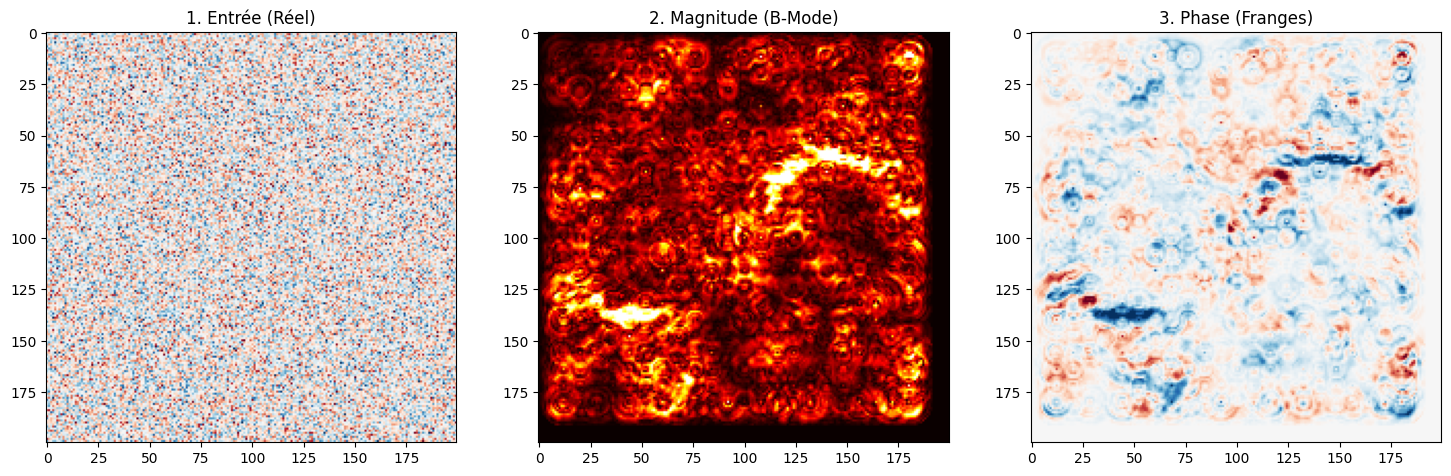

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon
import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor

tl.set_backend('numpy')

# ==========================================
# 1. Données IQ (Simulation plus propre)
# ==========================================
n_tx, nz, nx = 5, 200, 200
f0 = 0.08  # [FIX] Fréquence plus basse pour éviter l'aliasing de phase

base_env = np.zeros((nz, nx))
for i in range(nx):
    z_val = int(100 + 40 * np.sin(i / 30.0))
    if 0 <= z_val < nz: base_env[z_val, i] = 1.0

from scipy.ndimage import gaussian_filter
base_env = gaussian_filter(base_env, sigma=1.5)
Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)
complex_base = base_env * carrier

# Bruit de fond plus léger pour stabiliser la phase
images_tx_iq = []
for _ in range(n_tx):
    noise = (np.random.normal(0, 0.5, (nz, nx)) + 1j * np.random.normal(0, 0.5, (nz, nx)))
    images_tx_iq.append(complex_base + noise)

images_tx_iq = np.array(images_tx_iq)

# ==========================================
# 2. Paramètres (Ajustés pour IQ)
# ==========================================
win_size, step = 25, 8 # [FIX] Fenêtres plus grandes pour mieux capturer l'onde
angles_rx = np.linspace(0, 180, 60, endpoint=False)

# Fenêtre de Tukey (plus de plateau au centre)
from scipy.signal.windows import tukey
w1 = tukey(win_size, alpha=0.5)
window_2d = np.outer(w1, w1)

output_iq = np.zeros((nz, nx), dtype=np.complex128)
weight_map = np.zeros((nz, nx))

# ==========================================
# 3. Traitement
# ==========================================
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        patch = images_tx_iq[:, z:z+win_size, x:x+win_size] * window_2d
        if np.max(np.abs(patch)) < 0.2: continue # [FIX] Seuil plus haut

        # Radon complexe
        rad_t = np.array([radon(p.real, angles_rx) + 1j*radon(p.imag, angles_rx) for p in patch])

        try:
            # [FIX] On augmente n_iter_max pour la convergence complexe
            w, factors = parafac(rad_t, rank=1, n_iter_max=100, init='random')
            recon_t = cp_to_tensor((w, factors))
            f_sino = np.mean(recon_t, axis=0)

            # iRadon complexe
            p_rec = iradon(f_sino.real, angles_rx, output_size=win_size) + \
                    1j*iradon(f_sino.imag, angles_rx, output_size=win_size)
            
            p_rec = np.clip(np.abs(p_rec), 0, None) * np.exp(1j * np.angle(p_rec))
            output_iq[z:z+win_size, x:x+win_size] += p_rec * window_2d
            weight_map[z:z+win_size, x:x+win_size] += window_2d
        except: continue

# Finalisation
mask = weight_map > 0
output_iq[mask] /= weight_map[mask]

# ==========================================
# 4. Affichage (Le secret est dans le VMAX)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(np.real(images_tx_iq[0]), cmap='RdBu', vmin=-1.5, vmax=1.5)
axes[0].set_title("1. Entrée (Réel)")

# [FIX] On utilise un percentile pour ne pas laisser les points brillants tuer le contraste
vmax_abs = np.percentile(np.abs(output_iq), 99)
axes[1].imshow(np.abs(output_iq), cmap='hot', vmin=0, vmax=vmax_abs)
axes[1].set_title("2. Magnitude (B-Mode)")

# [FIX] On zoome sur une zone précise pour voir les franges
axes[2].imshow(np.real(output_iq), cmap='RdBu', vmin=-vmax_abs, vmax=vmax_abs)
axes[2].set_title("3. Phase (Franges)")

plt.show()

Reconstruction avec recalage de phase...


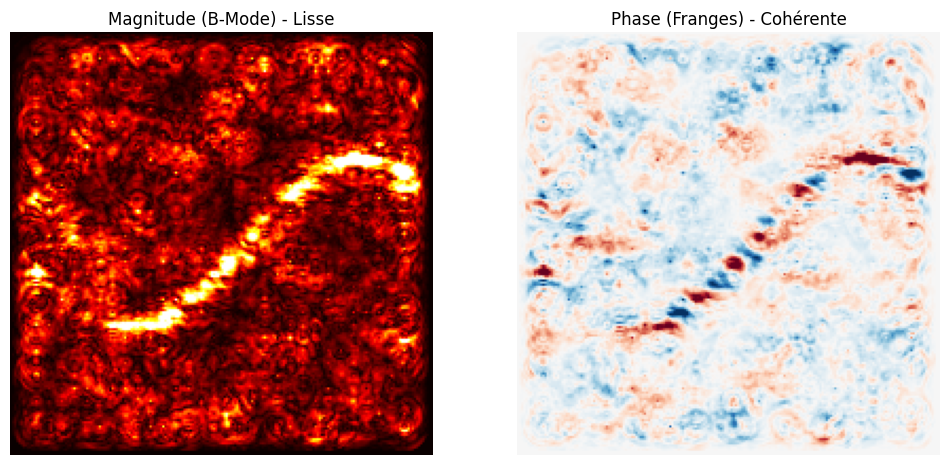

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon
import tensorly as tl
from tensorly.decomposition import parafac
from tensorly.cp_tensor import cp_to_tensor

tl.set_backend('numpy')

# ==========================================
# 1. Données IQ (Simulation)
# ==========================================
n_tx, nz, nx = 5, 200, 200
f0 = 0.08 
base_env = np.zeros((nz, nx))
for i in range(nx):
    z_val = int(100 + 40 * np.sin(i / 35.0))
    if 0 <= z_val < nz: base_env[z_val, i] = 1.0

from scipy.ndimage import gaussian_filter
base_env = gaussian_filter(base_env, sigma=1.5)
Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z)
complex_base = base_env * carrier

images_tx_iq = []
for _ in range(n_tx):
    noise = (np.random.normal(0, 0.4, (nz, nx)) + 1j * np.random.normal(0, 0.4, (nz, nx)))
    images_tx_iq.append(complex_base + noise)
images_tx_iq = np.array(images_tx_iq)

# ==========================================
# 2. Paramètres
# ==========================================
win_size, step = 25, 6
angles_rx = np.linspace(0, 180, 60, endpoint=False)
from scipy.signal.windows import tukey
window_2d = np.outer(tukey(win_size, alpha=0.5), tukey(win_size, alpha=0.5))

output_iq = np.zeros((nz, nx), dtype=np.complex128)
weight_map = np.zeros((nz, nx))

# ==========================================
# 3. Traitement avec PHASE CORRECTION
# ==========================================
print("Reconstruction avec recalage de phase...")
for z in range(0, nz - win_size + 1, step):
    for x in range(0, nx - win_size + 1, step):
        patch = images_tx_iq[:, z:z+win_size, x:x+win_size] * window_2d
        if np.max(np.abs(patch)) < 0.2: continue 

        # Radon + Tensorly
        rad_t = np.array([radon(p.real, angles_rx) + 1j*radon(p.imag, angles_rx) for p in patch])
        try:
            w, factors = parafac(rad_t, rank=1, n_iter_max=100)
            f_sino = np.mean(cp_to_tensor((w, factors)), axis=0)
            p_rec = iradon(f_sino.real, angles_rx, output_size=win_size) + \
                    1j*iradon(f_sino.imag, angles_rx, output_size=win_size)
            
            # --- BLOC : PHASE CORRECTION (Recalage) ---
            # On regarde la phase déjà présente sur la toile à cet endroit
            existing_region = output_iq[z:z+win_size, x:x+win_size]
            
            # Si on a déjà posé des patchs ici, on calcule la différence de phase moyenne
            if np.sum(np.abs(existing_region)) > 0:
                # On calcule l'angle de déphasage optimal (Cross-correlation à l'origine)
                phase_diff = np.angle(np.sum(existing_region * np.conj(p_rec)))
                p_rec *= np.exp(1j * phase_diff) # On "pousse" la phase du patch pour l'aligner
            # ------------------------------------------

            output_iq[z:z+win_size, x:x+win_size] += p_rec * window_2d
            weight_map[z:z+win_size, x:x+win_size] += window_2d
        except: continue

# Normalisation
mask = weight_map > 0
output_iq[mask] /= weight_map[mask]

# ==========================================
# 4. Affichage
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
vmax = np.percentile(np.abs(output_iq), 99)

axes[0].imshow(np.abs(output_iq), cmap='hot', vmin=0, vmax=vmax)
axes[0].set_title("Magnitude (B-Mode) - Lisse")

axes[1].imshow(np.real(output_iq), cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1].set_title("Phase (Franges) - Cohérente")

for ax in axes: ax.axis('off')
plt.show()